# Notebook 1: Text Generation with GPT-2

In this notebook we explore **autoregressive text generation** using OpenAI's GPT-2 model via the Hugging Face `transformers` library.

## Learning Objectives
- Understand how causal language models generate text token-by-token
- Load a pretrained GPT-2 model and tokenizer
- Use the `pipeline` API for quick inference
- Control generation with parameters (max length, temperature, top-k, top-p)
- Generate text directly with `model.generate()`

## Background
GPT-2 (Generative Pre-trained Transformer 2) is a large transformer-based language model trained by OpenAI on ~40 GB of internet text. It learns to predict the next token in a sequence, which makes it capable of open-ended text generation. We will use the `gpt2` checkpoint (124 M parameters) which can run on CPU.

## 1. Install & Import Dependencies

In [1]:
# Install required packages (run once; skip if already installed)
# !pip install transformers torch

In [1]:
import warnings
warnings.filterwarnings('ignore')

import torch
from transformers import pipeline, GPT2Tokenizer, GPT2LMHeadModel

print(f"PyTorch version : {torch.__version__}")
device = 0 if torch.cuda.is_available() else -1
print(f"Using device    : {'GPU' if device == 0 else 'CPU'}")

PyTorch version : 2.11.0+cpu
Using device    : CPU


## 2. Quick Generation with the Pipeline API

The `pipeline` helper is the simplest entry point. It wraps tokenization, model inference, and decoding into a single callable.

In [2]:
# Load the text-generation pipeline with the small GPT-2 checkpoint
generator = pipeline(
    "text-generation",
    model="gpt2",
    device=device,
    truncation=True,
)
print("Pipeline loaded successfully.")

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Pipeline loaded successfully.


In [3]:
prompt = "Once upon a time in a land far away"

outputs = generator(
    prompt,
    max_new_tokens=80,
    num_return_sequences=2,
    do_sample=True,
    temperature=0.9,
    top_k=50,
    top_p=0.95,
)

for i, out in enumerate(outputs, 1):
    print(f"--- Generation {i} ---")
    print(out["generated_text"])
    print()

[transformers] Passing `generation_config` together with generation-related arguments=({'temperature', 'top_k', 'top_p', 'do_sample', 'max_new_tokens', 'num_return_sequences'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Both `max_new_tokens` (=80) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


--- Generation 1 ---
Once upon a time in a land far away a man, having a bad dream, came to the great temple of Samael, he went on his journey to buy a woman's dowry of six thousand liras, then a good man, a good man, went on his journey to purchase a man's dowry of eight thousand liras, then a good man, a good man went on his journey to buy a man

--- Generation 2 ---
Once upon a time in a land far away, you would have to fight in battle to protect the land from invaders. The heroes are the only ones who can fight the invaders, and their story is one of the only ones who can do so.

For all of you who have enjoyed the game, I am sorry to see your disappointment. All of you have done your job and I hope you will appreciate the game more. Thanks for



### 2.1 Understanding Generation Parameters

| Parameter | Effect |
|---|---|
| `max_new_tokens` | Maximum number of **new** tokens to generate (does not count the prompt) |
| `do_sample` | If `True`, sample from the probability distribution; if `False`, use greedy decoding |
| `temperature` | Scales logits before sampling. < 1 makes distribution sharper (more deterministic); > 1 makes it flatter (more random) |
| `top_k` | Keep only the top-k tokens at each step (nucleus filtering) |
| `top_p` | Keep the smallest set of tokens whose cumulative probability exceeds *p* (nucleus / top-p sampling) |
| `num_return_sequences` | How many independent sequences to generate |

## 3. Low-Level Generation with Tokenizer + Model

Working directly with the tokenizer and model gives us finer control and helps understand what happens under the hood.

In [2]:
# Load tokenizer and model explicitly
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2LMHeadModel.from_pretrained("gpt2")
model.eval()

# GPT-2 does not have a pad token; we set it to the eos token
tokenizer.pad_token = tokenizer.eos_token

print(f"Vocabulary size : {tokenizer.vocab_size}")
print(f"Model parameters: {model.num_parameters():,}")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Vocabulary size : 50257
Model parameters: 124,439,808


In [5]:
def generate_text(
    prompt: str,
    max_new_tokens: int = 100,
    temperature: float = 0.8,
    top_k: int = 50,
    top_p: float = 0.92,
) -> str:
    """Tokenize a prompt, run model.generate(), and decode the result."""
    inputs = tokenizer(prompt, return_tensors="pt")
    input_ids = inputs["input_ids"]

    with torch.no_grad():
        output_ids = model.generate(
            input_ids,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=temperature,
            top_k=top_k,
            top_p=top_p,
            pad_token_id=tokenizer.eos_token_id,
        )

    # Decode only the newly generated tokens
    new_tokens = output_ids[0][input_ids.shape[-1]:]
    return tokenizer.decode(new_tokens, skip_special_tokens=True)


# Try different prompts
prompts = [
    "The future of artificial intelligence is",
    "In the year 2050, scientists discovered",
    "The best way to learn a new programming language is",
]

for p in prompts:
    continuation = generate_text(p)
    print(f"PROMPT   : {p}")
    print(f"GENERATED: {continuation}")
    print("-" * 60)

[transformers] The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


PROMPT   : The future of artificial intelligence is
GENERATED:  still being explored.

"We are currently in the early stages of that and there's still a lot to learn from," said Tom Leggett, senior vice president of product development at Avio. "We're excited to see what it can learn from the new technologies, and hopefully see if that's enough for us."

The company is also taking the lead in building a new smartwatch, called the "Lemon" smartwatch, which is designed to monitor, read and
------------------------------------------------------------
PROMPT   : In the year 2050, scientists discovered
GENERATED:  that the "brain has evolved to be able to withstand and cope with the challenges of the environment," so it has evolved to avoid this. The brain has evolved to be able to deal with the challenges of the environment. It is also a very good model for studying the evolution of disease.

So it's very important that we take a look at the evolution of the brain and how it evolved over t

## 4. Greedy vs. Sampling Decoding

Let's compare **greedy** (always pick the highest-probability token) with **sampling** (randomly draw from the distribution) for the same prompt.

In [6]:
prompt = "Deep learning has transformed the field of natural language processing because"
inputs = tokenizer(prompt, return_tensors="pt")

# Greedy decoding
with torch.no_grad():
    greedy_ids = model.generate(
        inputs["input_ids"],
        max_new_tokens=60,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id,
    )

# Sampling decoding
with torch.no_grad():
    sample_ids = model.generate(
        inputs["input_ids"],
        max_new_tokens=60,
        do_sample=True,
        temperature=1.0,
        top_k=50,
        pad_token_id=tokenizer.eos_token_id,
    )

greedy_text = tokenizer.decode(greedy_ids[0], skip_special_tokens=True)
sample_text = tokenizer.decode(sample_ids[0], skip_special_tokens=True)

print("=== Greedy Decoding ===")
print(greedy_text)
print()
print("=== Sampling Decoding ===")
print(sample_text)

=== Greedy Decoding ===
Deep learning has transformed the field of natural language processing because it has enabled us to understand the human brain's ability to process information.

The new research, published in the journal Nature Neuroscience, shows that the brain's ability to process information is also changing.

"We have shown that the brain's ability to process information is changing, and that

=== Sampling Decoding ===
Deep learning has transformed the field of natural language processing because it integrates information from multiple, complex neural networks into one. The technique relies on non-linear learning or reinforcement learning so that the goal of the algorithm may be to perform highly accurate tasks and be successful.

"This study shows that as we expand our knowledge of cognitive processes and technologies over the


## 5. Beam Search

Beam search keeps the top-*n* candidate sequences at each step and is a good middle ground between greedy and pure sampling.

In [7]:
prompt = "Renewable energy sources such as solar and wind power"
inputs = tokenizer(prompt, return_tensors="pt")

with torch.no_grad():
    beam_ids = model.generate(
        inputs["input_ids"],
        max_new_tokens=60,
        num_beams=5,
        early_stopping=True,
        no_repeat_ngram_size=2,
        pad_token_id=tokenizer.eos_token_id,
    )

beam_text = tokenizer.decode(beam_ids[0], skip_special_tokens=True)
print("=== Beam Search (num_beams=5) ===")
print(beam_text)

=== Beam Search (num_beams=5) ===
Renewable energy sources such as solar and wind power.

"This is a huge step forward in the fight against climate change," he said in a statement. "We will continue to work with our partners and partners around the world to make sure that we are doing everything we can to reduce our carbon footprint."


## 6. Inspecting Token Probabilities

Let's peek inside the model and visualise the top-10 next-token probabilities for a given prompt.

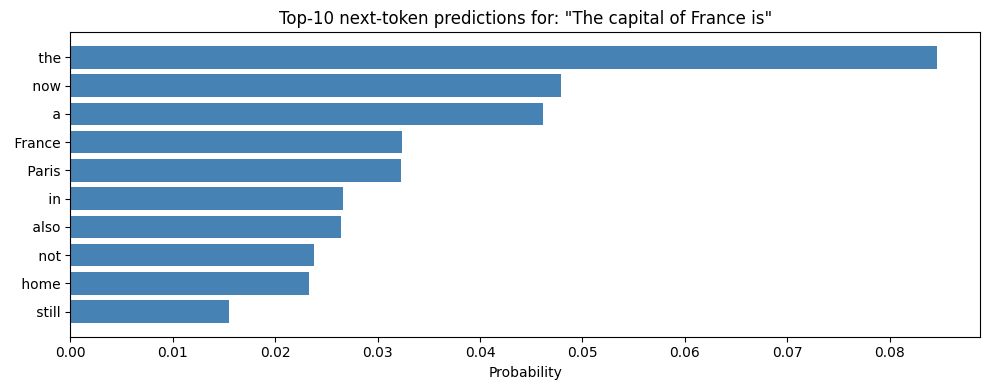


Top-10 predictions:
  ' the'          0.0846
  ' now'          0.0479
  ' a'            0.0462
  ' France'       0.0324
  ' Paris'        0.0322
  ' in'           0.0266
  ' also'         0.0264
  ' not'          0.0238
  ' home'         0.0233
  ' still'        0.0155


In [3]:
import torch.nn.functional as F
import matplotlib.pyplot as plt

prompt = "The capital of France is"
inputs = tokenizer(prompt, return_tensors="pt")

with torch.no_grad():
    logits = model(**inputs).logits  # shape: (1, seq_len, vocab_size)

# Take the logits at the last token position
last_logits = logits[0, -1, :]               # (vocab_size,)
probs = F.softmax(last_logits, dim=-1)

top_probs, top_ids = torch.topk(probs, 10)
top_tokens = [tokenizer.decode([idx]) for idx in top_ids]

plt.figure(figsize=(10, 4))
bars = plt.barh(top_tokens[::-1], top_probs.numpy()[::-1], color="steelblue")
plt.xlabel("Probability")
plt.title(f'Top-10 next-token predictions for: "{prompt}"')
plt.tight_layout()
plt.show()

print("\nTop-10 predictions:")
for token, prob in zip(top_tokens, top_probs.numpy()):
    print(f"  {repr(token):<15} {prob:.4f}")

## 7. Summary

In this notebook we:
- Used the Hugging Face `pipeline` API for quick GPT-2 text generation
- Controlled generation quality with `temperature`, `top_k`, and `top_p`
- Compared greedy, sampling, and beam-search decoding strategies
- Visualised the next-token probability distribution

**Next steps**: Head to `02_conversational_chatbot.ipynb` to see how a dialogue-specific model (BlenderBot) handles multi-turn conversation.